In [1]:
import numpy as np
import re
import matplotlib.pyplot as plt
import xarray as xr
import pickle

In [2]:
import re
import numpy as np

FLOAT_RE = r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?"

def parse_training_file_cloudsignal_flexible(file_path, channels, assume_val_is_last_channels=True):
    """
    Parse wrapped 'Training history' where each epoch spans multiple lines.

    Layout per epoch (numeric):
      epoch, lr,
      train_total,
      train_channels (len(channels)),
      val_total,
      val_channels (whatever remains)

    If validation prints fewer channel losses than training, we store only those.
    If assume_val_is_last_channels=True, we associate val values with the last N channels.
    """
    n_train = len(channels)

    epoch_header_re = re.compile(r"^\s*(\d+)\s+(" + FLOAT_RE + r")\b")

    def nums_in_line(line):
        return [float(x) for x in re.findall(FLOAT_RE, line)]

    epochs, lrs = [], []
    train_total, val_total = [], []
    train_ch, val_ch = [], []

    with open(file_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        m = epoch_header_re.match(lines[i])
        if not m:
            i += 1
            continue

        epoch = int(m.group(1))
        lr = float(m.group(2))

        block_nums = nums_in_line(lines[i])  # includes epoch & lr
        i += 1
        while i < len(lines) and not epoch_header_re.match(lines[i]):
            more = nums_in_line(lines[i])
            if more:
                block_nums.extend(more)
            i += 1

        # Need at least: epoch, lr, train_total, train_channels..., val_total
        min_needed = 2 + 1 + n_train + 1
        if len(block_nums) < min_needed:
            raise ValueError(
                f"{file_path}: epoch {epoch} too few numbers "
                f"({len(block_nums)} found, {min_needed} needed). Got: {block_nums}"
            )

        pos = 2  # skip epoch, lr
        t_total = block_nums[pos]; pos += 1

        t_ch = block_nums[pos:pos + n_train]
        pos += n_train

        v_total = block_nums[pos]; pos += 1
        v_ch = block_nums[pos:]  # remaining (can be shorter than n_train)

        epochs.append(epoch)
        lrs.append(lr)
        train_total.append(t_total)
        val_total.append(v_total)
        train_ch.append(t_ch)
        val_ch.append(v_ch)

    # Convert (val_ch is ragged -> pad with NaN to rectangular array)
    max_val = max(len(v) for v in val_ch) if val_ch else 0
    val_arr = np.full((len(val_ch), max_val), np.nan, dtype=float)
    for r, v in enumerate(val_ch):
        val_arr[r, :len(v)] = v

    train_arr = np.array(train_ch, dtype=float)

    # Optional: assign val channel names as last N channels
    if assume_val_is_last_channels:
        val_channel_names = channels[-max_val:] if max_val > 0 else []
    else:
        val_channel_names = [f"val_metric_{k}" for k in range(max_val)]

    return {
        "epochs": np.array(epochs, dtype=int),
        "lrs": np.array(lrs, dtype=float),
        "train_total": np.array(train_total, dtype=float),
        "val_total": np.array(val_total, dtype=float),
        "train_channels": train_arr,          # shape (n_epochs, n_train)
        "val_channels": val_arr,              # shape (n_epochs, max_val), padded with NaN
        "train_channel_names": list(channels),
        "val_channel_names": list(val_channel_names),
        "n_val_channels_in_file": max_val,
    }

In [4]:
channels = [
    "CloudSignal31","CloudSignal32","CloudSignal33","CloudSignal34","CloudSignal35",
    "CloudSignal36","CloudSignal41","CloudSignal42","CloudSignal43","CloudSignal44",
]

file_main = "../../../DataStorage/AWS/for_cloud_filtering/training_metrics/training_260304.out"
stats = parse_training_file_cloudsignal_flexible(file_main, channels)

print(stats["n_val_channels_in_file"])
print(stats["val_channel_names"])

7
['CloudSignal34', 'CloudSignal35', 'CloudSignal36', 'CloudSignal41', 'CloudSignal42', 'CloudSignal43', 'CloudSignal44']


In [32]:
with open("../../DataStorage/AWS/aws_train_dataset.pkl", 'rb') as file:
    training_data_old = pickle.load(file)

with open("../../DataStorage/AWS/aws_validate_dataset.pkl", 'rb') as file:
    val_data_old = pickle.load(file)
    

FileNotFoundError: [Errno 2] No such file or directory: '../../DataStorage/AWS/aws_train_dataset.pkl'

In [33]:
stats

{'epochs': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  1,  2,  3,  4,  5,  6,  7,
         8,  9, 10]),
 'lrs': array([0.01  , 0.0098, 0.009 , 0.0079, 0.0065, 0.005 , 0.0035, 0.0021,
        0.001 , 0.0002, 0.001 , 0.001 , 0.0009, 0.0008, 0.0007, 0.0005,
        0.0003, 0.0002, 0.0001, 0.    ]),
 'train_total': array([0.337, 0.19 , 0.184, 0.179, 0.176, 0.173, 0.171, 0.17 , 0.169,
        0.168, 0.24 , 0.185, 0.175, 0.169, 0.166, 0.162, 0.159, 0.157,
        0.156, 0.155]),
 'val_total': array([0.19 , 0.113, 0.109, 0.106, 0.103, 0.102, 0.101, 0.101, 0.1  ,
        0.1  , 0.126, 0.106, 0.101, 0.097, 0.094, 0.09 , 0.088, 0.087,
        0.086, 0.085]),
 'train_channels': array([[0.976, 0.367, 2.084, 3.635, 0.214, 0.16 , 0.101, 1.882, 0.835,
         0.067],
        [0.636, 0.213, 0.177, 0.67 , 0.123, 0.088, 0.06 , 0.105, 0.067,
         0.042],
        [0.615, 0.207, 0.191, 0.74 , 0.119, 0.084, 0.057, 0.12 , 0.069,
         0.04 ],
        [0.596, 0.203, 0.163, 0.603, 0.115, 0.081, 0.0

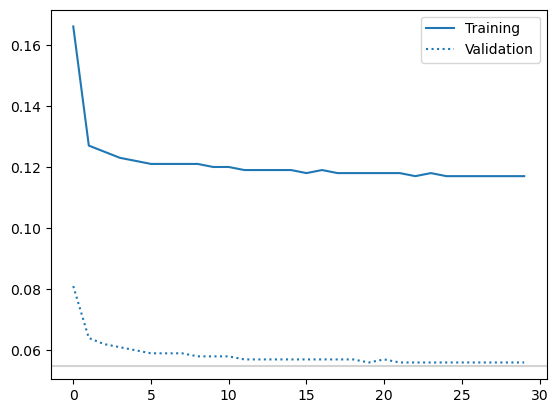

In [7]:
fig, ax = plt.subplots()

ax.plot(np.arange(0, len(stats["epochs"]), 1), stats["train_total"], c="C0", label="Training")
#ax.plot(range(len(epochs)), train_fwp, c="C1", label="FWP")
#ax.plot(range(len(epochs)), train_fwp_zm, c="C2", label="Zm")
#ax.plot(range(len(epochs)), train_fwp_dm, c="C3", label="Dm")

ax.plot(np.arange(0, len(stats["epochs"]), 1), stats["val_total"], c="C0", ls=":", label="Validation")
#ax.plot(range(len(epochs)), val_fwp, c="C1", ls=":")
#ax.plot(range(len(epochs)), val_fwp_zm, c="C2", ls=":")


#ax.plot(0,0, ls="-", c="grey", label="Training loss")
#ax.plot(0,0, ls=":", c="grey", label="Validation loss")

ax.axhline(0.055, c="lightgrey")
#ax.set_ylim([0.65, 0.74])
#ax.set_xlim([0,90])
ax.legend()

#plt.savefig(f"figures/AWS_model_training_25-11-21.png", dpi=400, facecolor="white")

In [5]:
training_data = xr.open_dataset("../../DataStorage/AWS/aws_database_2025-11-10_training_reduced.nc")
val_data = xr.open_dataset("../../DataStorage/AWS/aws_database_2025-11-10_validation_reduced.nc")


In [6]:
training_data_old

{'Ta_Allsky_AWS21': array([217.26398, 217.74112, 217.34988, ..., 280.26254, 280.57205,
        281.111  ], dtype=float32),
 'Ta_Allsky_AWS31': array([244.41295, 247.00569, 248.3523 , ..., 285.83542, 285.88004,
        286.27692], dtype=float32),
 'Ta_Allsky_AWS32': array([257.7257 , 259.33194, 259.88882, ..., 279.12177, 279.07755,
        279.15375], dtype=float32),
 'Ta_Allsky_AWS33': array([257.7236 , 258.3121 , 258.57413, ..., 270.45056, 270.53705,
        270.6848 ], dtype=float32),
 'Ta_Allsky_AWS34': array([253.79813, 254.03273, 254.1918 , ..., 264.88745, 265.12372,
        265.36642], dtype=float32),
 'Ta_Allsky_AWS35': array([246.80098, 246.90973, 246.99933, ..., 258.89453, 259.3473 ,
        259.73068], dtype=float32),
 'Ta_Allsky_AWS36': array([240.41563, 240.48679, 240.54266, ..., 253.96916, 254.55879,
        255.03596], dtype=float32),
 'Ta_Allsky_AWS41': array([242.16147, 242.29494, 242.42363, ..., 254.76642, 255.31326,
        255.75691], dtype=float32),
 'Ta_Allsky_AWS4

In [25]:
fwp_bins = np.logspace(-4, 1.5, num=100)
zm_bins = np.linspace(-1000, 20000, 50)
dm_bins = np.linspace(0, 0.0015, 100)
lat_bins = np.linspace(-70, 70, 70)
Ta_bins = np.linspace(80, 300, 221)

units = {
    "fwp": "kg m$^{-2}$",
    "iwc": "kg m$^{-3}$",
    "zm": "km",
    "dm": "$\mu$m",
    "slwp": "kg m$^{-2}$",
}

['Ta_Allsky_AWS21', 'Ta_Allsky_AWS31', 'Ta_Allsky_AWS32', 'Ta_Allsky_AWS33', 'Ta_Allsky_AWS34', 'Ta_Allsky_AWS35', 'Ta_Allsky_AWS36', 'Ta_Allsky_AWS41', 'Ta_Allsky_AWS42', 'Ta_Allsky_AWS43', 'Ta_Allsky_AWS44']


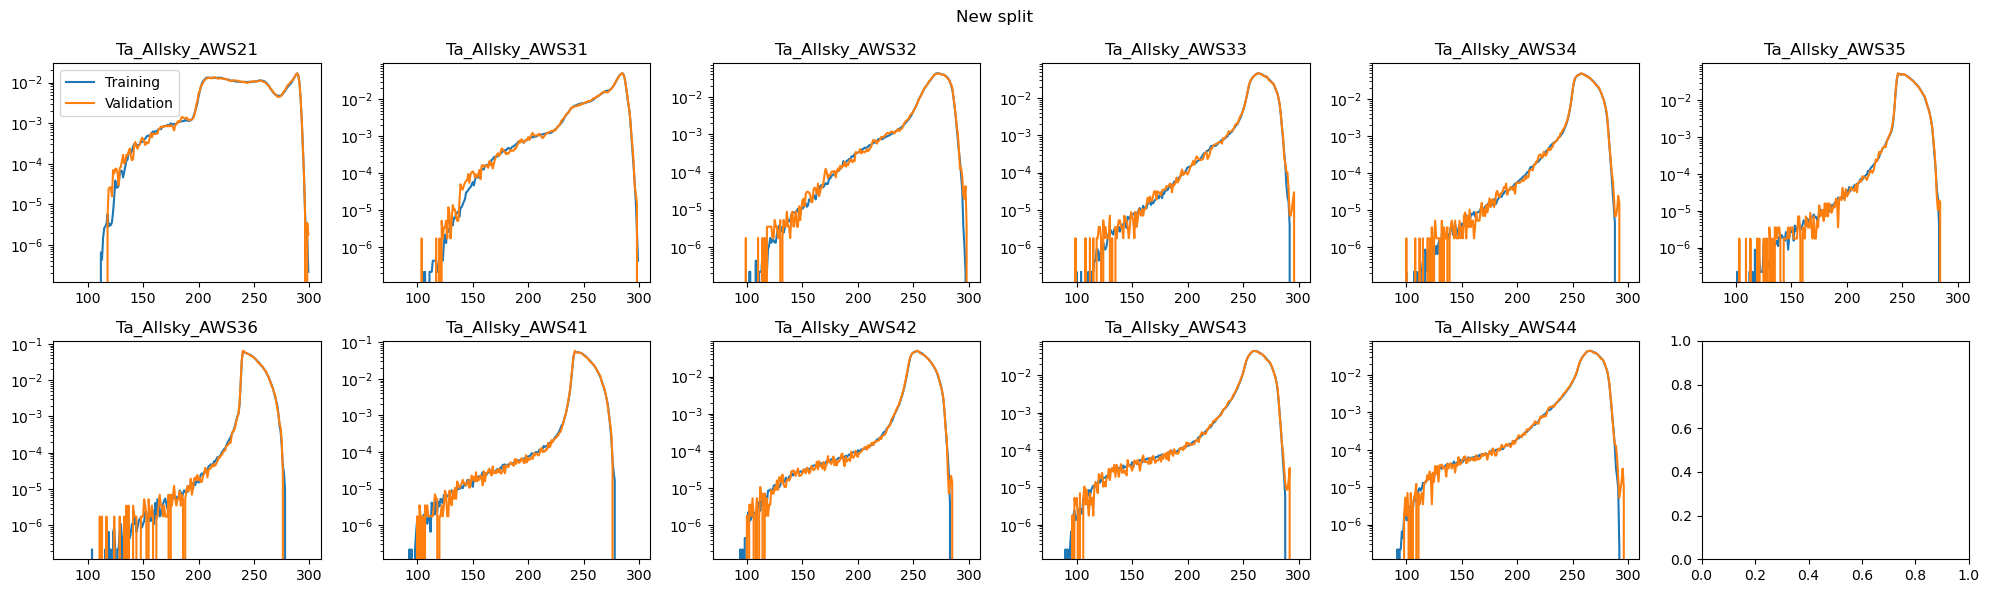

In [71]:
fig, ax = plt.subplots(2, 6, figsize=(20,6))

axes = ax.flatten()

channels = vars_with_training_data = [v for v in training_data.variables if "Ta" in v]
print(vars_with_training_data)


for i, channel in enumerate(channels):
    
    Ta_train = training_data[f'{channel}']
    counts_train, _ = np.histogram(Ta_train, bins=Ta_bins, density=True)

    Ta_val = val_data[f'{channel}']
    counts_val, _ = np.histogram(Ta_val, bins=Ta_bins, density=True)

    axes[i].plot(Ta_bins[:-1], counts_train, label="Training")
    axes[i].plot(Ta_bins[:-1], counts_val, label="Validation")

    axes[i].set_yscale("log")

    axes[i].set_title(f'{channel}')

axes[0].legend()

fig.suptitle("New split")

fig.tight_layout()

plt.savefig(f"figures/AWS_new_split.png", dpi=400, facecolor="white")

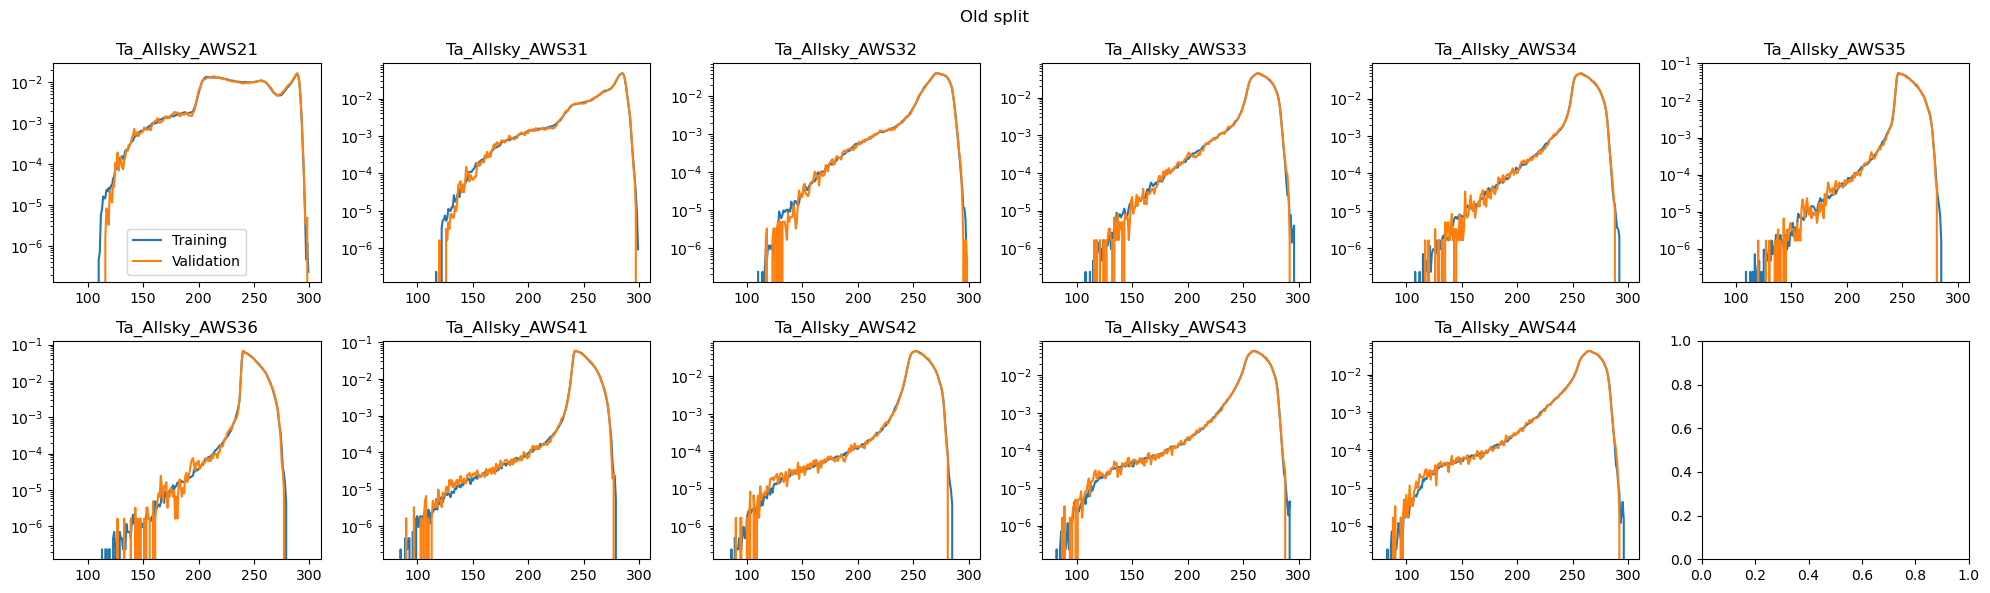

In [72]:
fig, ax = plt.subplots(2, 6, figsize=(20,6))

axes = ax.flatten()

channels = [v for v in training_data_old.keys() if "Ta_Allsky" in v]


for i, channel in enumerate(channels):
    
    Ta_train = training_data_old[f'{channel}']
    counts_train, _ = np.histogram(Ta_train, bins=Ta_bins, density=True)

    Ta_val = val_data_old[f'{channel}']
    counts_val, _ = np.histogram(Ta_val, bins=Ta_bins, density=True)

    axes[i].plot(Ta_bins[:-1], counts_train, label="Training")
    axes[i].plot(Ta_bins[:-1], counts_val, label="Validation")

    axes[i].set_yscale("log")

    axes[i].set_title(f'{channel}')

axes[0].legend()

fig.suptitle("Old split")

fig.tight_layout()

plt.savefig(f"figures/AWS_old_split.png", dpi=400, facecolor="white")

In [33]:
training_data

<xarray.Dataset> Size: 292MB
Dimensions:          (number: 4558231)
Dimensions without coordinates: number
Data variables: (12/16)
    Ta_Allsky_AWS21  (number) float32 18MB 197.4 199.5 203.8 ... 250.9 247.5
    Ta_Allsky_AWS31  (number) float32 18MB 240.7 241.4 244.9 ... 265.6 266.2
    Ta_Allsky_AWS32  (number) float32 18MB 259.3 259.3 260.5 ... 263.0 263.8
    Ta_Allsky_AWS33  (number) float32 18MB 258.4 258.5 258.8 ... 259.7 260.3
    Ta_Allsky_AWS34  (number) float32 18MB 255.4 255.6 255.8 ... 256.8 257.1
    Ta_Allsky_AWS35  (number) float32 18MB 251.5 251.8 252.0 ... 252.6 252.7
    ...               ...
    Ta_Allsky_AWS44  (number) float32 18MB 257.5 257.3 257.6 ... 257.2 259.3
    MirrorAngle      (number) float32 18MB ...
    Fwp              (number) float32 18MB ...
    Fwp_Dm           (number) float32 18MB ...
    Fwp_Zm           (number) float32 18MB ...
    Latitude         (number) float32 18MB ...
Attributes:
    created_with:  easy_arts 36d79facb5fb91ae319408c6dcd98ab53de8d0cc (dirty)

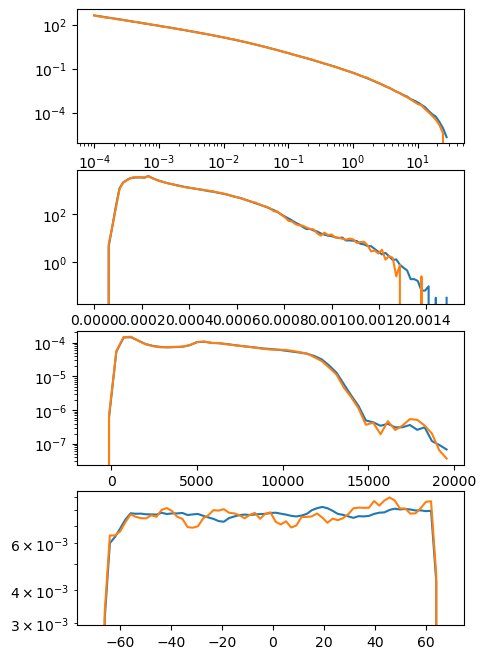

In [54]:
fig, ax = plt.subplots(4, figsize=(5,8))


counts_train, _ = np.histogram(training_data['Fwp'], bins=fwp_bins, density=True)
counts_val, _ = np.histogram(val_data['Fwp'], bins=fwp_bins, density=True)

ax[0].plot(fwp_bins[:-1], counts_train)
ax[0].plot(fwp_bins[:-1], counts_val)
ax[0].set_xscale("log")
ax[0].set_yscale("log")

counts_train, _ = np.histogram(training_data['Fwp_Dm'], bins=dm_bins, density=True)
counts_val, _ = np.histogram(val_data['Fwp_Dm'], bins=dm_bins, density=True)

ax[1].plot(dm_bins[:-1], counts_train)
ax[1].plot(dm_bins[:-1], counts_val)
ax[1].set_yscale("log")

counts_train, _ = np.histogram(training_data['Fwp_Zm'], bins=zm_bins, density=True)
counts_val, _ = np.histogram(val_data['Fwp_Zm'], bins=zm_bins, density=True)

ax[2].plot(zm_bins[:-1], counts_train)
ax[2].plot(zm_bins[:-1], counts_val)
#ax[2].set_xscale("log")
ax[2].set_yscale("log")

counts_train, _ = np.histogram(training_data['Latitude'], bins=lat_bins, density=True)
counts_val, _ = np.histogram(val_data['Latitude'], bins=lat_bins, density=True)

ax[3].plot(lat_bins[:-1], counts_train)
ax[3].plot(lat_bins[:-1], counts_val)
#ax[3].set_xscale("log")
ax[3].set_yscale("log")
